<h1 style="background-color:#0f172a; color:#38bdf8; padding:15px; border-radius:8px; text-align:center;">
🧪 Taller: Clínica de Modelos — Auditoría y Especialización V1
</h1>

<h3 style="text-align:center; color:#1e293b;">
Diagnóstico de Confusiones, Diseño Jerárquico y Estrategias de Optimización
</h3>

<h3 style="color:#0f172a;">
Kevin Julian Guerrero Penagos - Laura Sophia Zapata Coronado
</h3>

<div style="background-color:#f1f5f9; padding:15px; border-radius:8px; border-left:5px solid #22c55e; font-family:Arial;">

<b>🎯 Objetivo del Taller:</b><br>
Identificar errores críticos en modelos de clasificación de aves, analizar patrones de confusión y diseñar una solución jerárquica especializada que permita mejorar el desempeño del sistema.

<br><br>

<b>🧠 Modelos evaluados:</b><br>
• VGG16 Fine-Tuned<br>
• EfficientNetB0<br>
• MobileNetV2 (Modelo Principal)

<br><br>

<b>📁 Dataset:</b> dataset_limpio_v7  
<b>🐦 Clases:</b> 45 especies de aves

</div>

<h1 style="background-color:#1e293b; color:white; padding:12px; border-radius:8px;">
🟢 FASE 1 — Evaluación Base del Modelo MobileNetV2
</h1>

<div style="background-color:#f8fafc; padding:15px; border-radius:8px; border-left:6px solid #3b82f6; font-family:Arial;">

<b>🎯 Objetivo:</b><br>
Evaluar el desempeño general del modelo MobileNetV2 utilizando el conjunto
de validación para identificar el comportamiento inicial del clasificador.

<br><br>

<b>📊 Dataset utilizado:</b>

<ul>
<li>Total imágenes: <b>2536</b></li>
<li>Total especies: <b>45</b></li>
<li>Resolución imágenes: <b>224x224</b></li>
<li>Normalización: <b>Rescale 1/255</b></li>
</ul>

<b>🧠 Modelo evaluado:</b>

<ul>
<li>MobileNetV2 Fine-Tuned</li>
</ul>

</div>

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

<h3 style="color:#0f172a;">📂 Preparación del Dataset de Evaluación</h3>

<div style="background-color:#ecfeff; padding:12px; border-radius:8px;">

Se carga el dataset de validación únicamente para evaluar el desempeño del modelo.
No se realiza entrenamiento en esta fase.

</div>

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_generator = datagen.flow_from_directory(
    "./dataset_limpio_v7",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("Total imágenes:", len(y_true))
print("Total especies:", len(class_names))

Found 2536 images belonging to 45 classes.
Total imágenes: 2536
Total especies: 45


<h3 style="color:#0f172a;">🧠 Evaluación Comparativa de Modelos</h3>

<div style="background-color:#ecfeff; padding:12px; border-radius:8px;">

Se evalúan tres arquitecturas profundas utilizando el mismo conjunto
de validación con el fin de comparar su capacidad de generalización
y detectar cuál modelo presenta mayores errores de clasificación.

<b>Modelos evaluados:</b>

<ul>
<li>VGG16 Fine-Tuned</li>
<li>EfficientNetB0</li>
<li>MobileNetV2 (Modelo Base)</li>
</ul>

</div>

In [9]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report

model_paths = {

    "VGG16": "modelo_aves_vgg16_finetune_V2_Fase2.keras",
    "EfficientNetB0": "EfficientNetB0_Fase2_finetune_taller.keras",
    "MobileNetV2": "modelo_aves_mobilenetv2_v1.keras"
}

reportes = {}

for nombre, path in model_paths.items():

    print(f"\n🧠 Evaluando modelo: {nombre}")

    model = tf.keras.models.load_model(path)

    test_generator.reset()

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    reportes[nombre] = report_dict

    print(f"✅ Reporte generado para {nombre}")


🧠 Evaluando modelo: VGG16
80/80 ━━━━━━━━━━━━━━━━━━━━ 54s 644ms/step
✅ Reporte generado para VGG16

🧠 Evaluando modelo: EfficientNetB0
80/80 ━━━━━━━━━━━━━━━━━━━━ 69s 784ms/step
✅ Reporte generado para EfficientNetB0

🧠 Evaluando modelo: MobileNetV2


/home/asnarck/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/asnarck/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/asnarck/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/a

80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 573ms/step
✅ Reporte generado para MobileNetV2


<h3 style="color:#0f172a;">📊 Reporte de Clasificación</h3>

<div style="background-color:#f0fdf4; padding:12px; border-radius:8px;">

Se analiza el desempeño por especie utilizando Precision,
Recall y F1-score. Esto permite identificar clases donde
el modelo presenta debilidades.

</div>

In [11]:
import pandas as pd

df_report = pd.DataFrame(
    reportes["MobileNetV2"]
).transpose()

df_report.head(50)

,precision,recall,f1-score,support
Aguililla_Caminera_Rupornis_magnirostris,0.901961,0.851852,0.876190,54.000000
Amazon_Kingfisher,0.900000,0.875000,0.887324,72.000000
Aratinga_Pertinaz_Eupsittula_pertinax,0.906250,0.878788,0.892308,33.000000
Bananaquit,0.896552,0.650000,0.753623,40.000000
Barred_Antshrike,0.925000,0.925000,0.925000,40.000000
Black_Vulture,0.500000,0.745455,0.598540,55.000000
Buco_Bobito,0.915493,0.970149,0.942029,67.000000
Caracara_Cabeza_Amarilla_Daptrius_chimachima,0.888889,0.927536,0.907801,69.000000
Carib_Grackle,0.755102,0.649123,0.698113,57.000000
Carpintero_Coronirrojo_Melanerpes_rubricapillus,0.948718,0.822222,0.880952,45.000000


<h3 style="color:#0f172a;">🔎 Identificación de Especies Problemáticas</h3>

<div style="background-color:#fff7ed; padding:12px; border-radius:8px;">

Se identifican automáticamente las especies cuyo Recall es inferior a 0.60,
indicando dificultad del modelo para reconocer correctamente estas aves.

</div>

In [13]:
reportes[nombre] = report_dict

In [14]:
import pandas as pd

df_reportes = {}

for nombre, reporte in reportes.items():

    df = pd.DataFrame(reporte).transpose()

    # quitamos accuracy y promedios
    df = df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")

    df_reportes[nombre] = df

print("✅ DataFrames creados para todos los modelos")

✅ DataFrames creados para todos los modelos


In [15]:
low_species_modelos = {}

for nombre, df in df_reportes.items():

    low_species = df[df["recall"] < 0.60] \
        .sort_values("recall")

    low_species_modelos[nombre] = low_species

    print(f"\n🔴 Especies con BAJO desempeño — {nombre}")
    display(low_species[["precision","recall","f1-score"]])


🔴 Especies con BAJO desempeño — VGG16


,precision,recall,f1-score
Carpintero_Coronirrojo_Melanerpes_rubricapillus,0.000000,0.000000,0.000000
Carpintero_Pecho_Punteado,0.000000,0.000000,0.000000
Tangara_Matorralera,0.000000,0.000000,0.000000
Tangara_Azulgris_Thraupis_episcopus,0.022222,0.039216,0.028369
Halcon_Fajado_Falco_femoralis,0.111111,0.085106,0.096386
Halcon_Peregrino_Falco_peregrinus,0.090909,0.117647,0.102564
jilguero_dorado_Sicalis_flaveola,0.351351,0.309524,0.329114
Zopilote_Comun_Coragyps_atratus,0.352941,0.333333,0.342857
Thick_billed_Euphonia,0.433333,0.361111,0.393939
Centzontle_Tropical_Mimus_gilvus,0.410714,0.433962,0.422018



🔴 Especies con BAJO desempeño — EfficientNetB0


,precision,recall,f1-score
Aguililla_Caminera_Rupornis_magnirostris,0.000000,0.0000,0.000000
Amazon_Kingfisher,0.000000,0.0000,0.000000
Aratinga_Pertinaz_Eupsittula_pertinax,0.000000,0.0000,0.000000
Bananaquit,0.000000,0.0000,0.000000
Barred_Antshrike,0.000000,0.0000,0.000000
Black_Vulture,0.000000,0.0000,0.000000
Buco_Bobito,0.000000,0.0000,0.000000
Caracara_Cabeza_Amarilla_Daptrius_chimachima,0.000000,0.0000,0.000000
Carib_Grackle,0.000000,0.0000,0.000000
Carpintero_Coronirrojo_Melanerpes_rubricapillus,0.000000,0.0000,0.000000



🔴 Especies con BAJO desempeño — MobileNetV2


,precision,recall,f1-score
Thick_billed_Euphonia,0.571429,0.111111,0.186047
Zopilote_Comun_Coragyps_atratus,0.391304,0.250000,0.305085
Tropical_Mockingbird,0.372549,0.413043,0.391753
jilguero_dorado_Sicalis_flaveola,0.500000,0.428571,0.461538
Centzontle_Tropical_Mimus_gilvus,0.413793,0.452830,0.432432
Saffron_Finch,0.538462,0.583333,0.560000


<h3 style="color:#0f172a;">🟢 Especies con Alto Desempeño</h3>

<div style="background-color:#ecfdf5; padding:12px; border-radius:8px;">

Se identifican las especies mejor aprendidas por cada modelo,
con Recall superior a 0.85.

</div>

In [17]:
high_species_modelos = {}

for nombre, df in df_reportes.items():

    high_species = df[df["recall"] > 0.85] \
        .sort_values("recall", ascending=False)

    high_species_modelos[nombre] = high_species

    print(f"\n🟢 Alto desempeño — {nombre}")
    display(high_species[["precision","recall","f1-score"]])


🟢 Alto desempeño — VGG16


,precision,recall,f1-score
Ibis_afeitado_Phimosus_infuscatus,0.942308,0.980000,0.960784
Hormiguero_Ventriblanco,0.886076,0.972222,0.927152
Buco_Bobito,0.915493,0.970149,0.942029
Moustached_Puffbird,0.953846,0.968750,0.961240
Momoto_Serrano_Momotus_aequatorialis,1.000000,0.950820,0.974790
Colibri_Capucha_Azul,0.980769,0.927273,0.953271
Saltador_Garganta_Ocre,0.905263,0.914894,0.910053
Aratinga_Pertinaz_Eupsittula_pertinax,0.967742,0.909091,0.937500
Gorrion_Chingolo_Zonotrichia_capensis,0.909091,0.909091,0.909091
tortolita_canela_Columbina_talpacoti,0.930233,0.909091,0.919540



🟢 Alto desempeño — EfficientNetB0


,precision,recall,f1-score
Saltador_Garganta_Ocre,0.03745,1.0,0.072197



🟢 Alto desempeño — MobileNetV2


,precision,recall,f1-score
Southern_Lapwing,0.940000,0.979167,0.959184
Buco_Bobito,0.915493,0.970149,0.942029
Moustached_Puffbird,0.939394,0.968750,0.953846
Carpintero_Pecho_Punteado,0.931034,0.964286,0.947368
Hormiguero_Ventriblanco,0.821429,0.958333,0.884615
tortolita_canela_Columbina_talpacoti,0.875000,0.954545,0.913043
Momoto_Serrano_Momotus_aequatorialis,0.966667,0.950820,0.958678
benteveo_pitangus_sulphuratus,0.945455,0.945455,0.945455
Saltariun_Barbiblanco,0.932432,0.945205,0.938776
Caracara_Cabeza_Amarilla_Daptrius_chimachima,0.888889,0.927536,0.907801


<h3 style="color:#0f172a;">🔥 Matrices de Confusión — Comparación de Modelos</h3>

<div style="background-color:#eef2ff; padding:12px; border-radius:8px;">

Se visualizan las matrices de confusión de VGG16, EfficientNetB0 y MobileNetV2
para analizar diferencias en los patrones de error.

</div>


🧠 Generando matriz de confusión: VGG16
80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 577ms/step


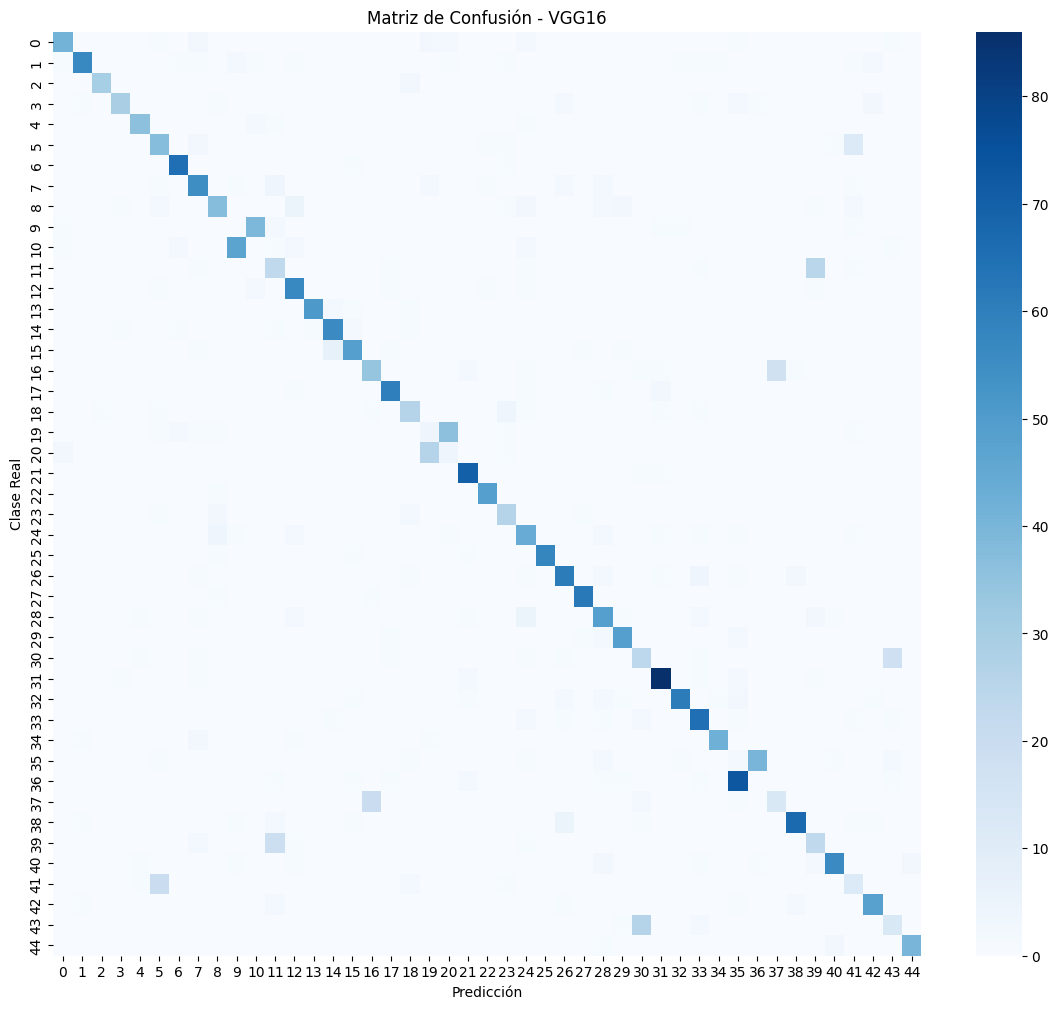


🧠 Generando matriz de confusión: EfficientNetB0
80/80 ━━━━━━━━━━━━━━━━━━━━ 65s 733ms/step


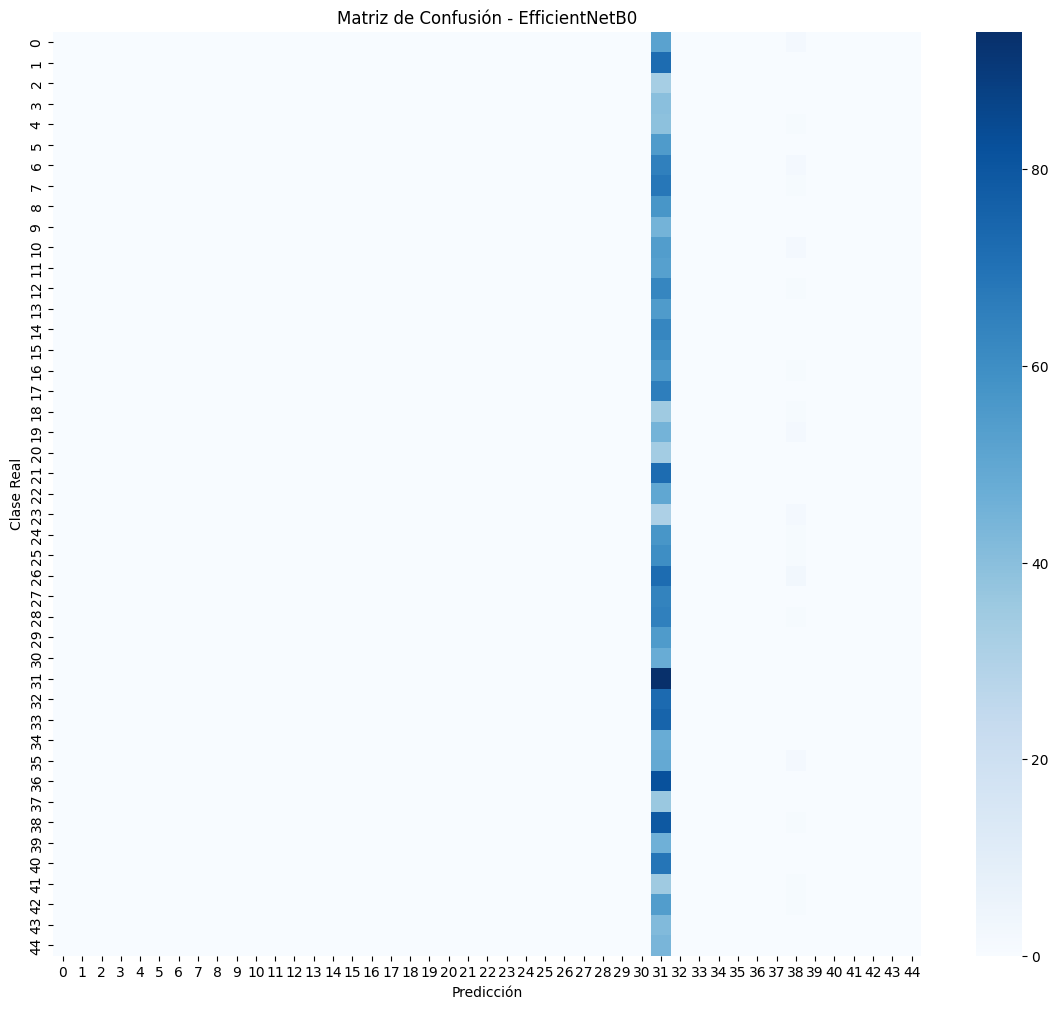


🧠 Generando matriz de confusión: MobileNetV2


/home/asnarck/tf_gpu/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 57 variables whereas the saved optimizer has 112 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


80/80 ━━━━━━━━━━━━━━━━━━━━ 56s 657ms/step


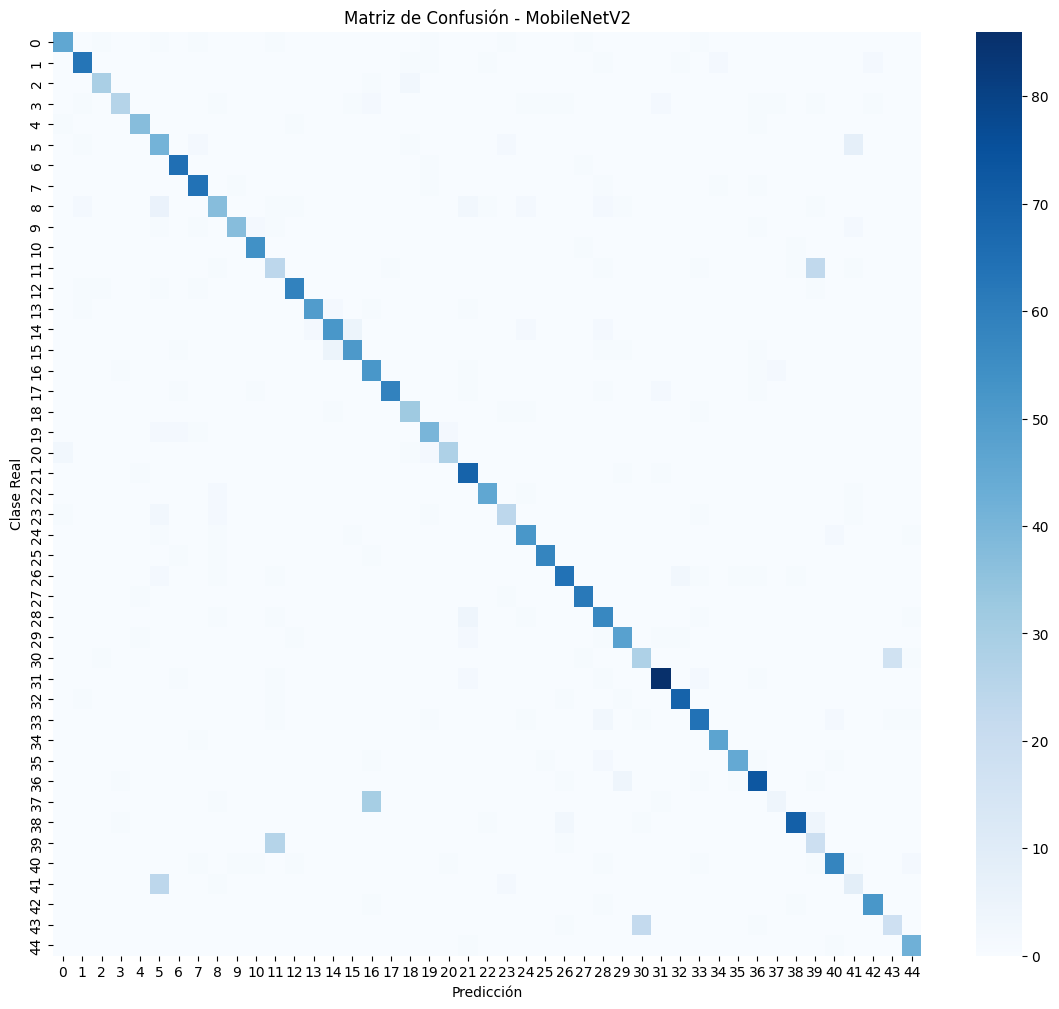

In [20]:
model_paths = {
    "VGG16": "modelo_aves_vgg16_finetune_V2_Fase2.keras",
    "EfficientNetB0": "EfficientNetB0_Fase2_finetune_taller.keras",
    "MobileNetV2": "modelo_aves_mobilenetv2_v1.keras"
}

for nombre, path in model_paths.items():

    print(f"\n🧠 Generando matriz de confusión: {nombre}")

    model = tf.keras.models.load_model(path)

    test_generator.reset()

    pred = model.predict(test_generator)

    y_pred = np.argmax(pred, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(14,12))
    sns.heatmap(cm, cmap="Blues")

    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase Real")

    plt.show()

<h3 style="color:#0f172a;">🔥 Matriz de Confusión — MobileNetV2</h3>

<div style="background-color:#eef2ff; padding:12px; border-radius:8px;">

La matriz de confusión permite visualizar qué especies son confundidas
entre sí.

</div>

/home/asnarck/tf_gpu/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 57 variables whereas the saved optimizer has 112 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


80/80 ━━━━━━━━━━━━━━━━━━━━ 53s 607ms/step


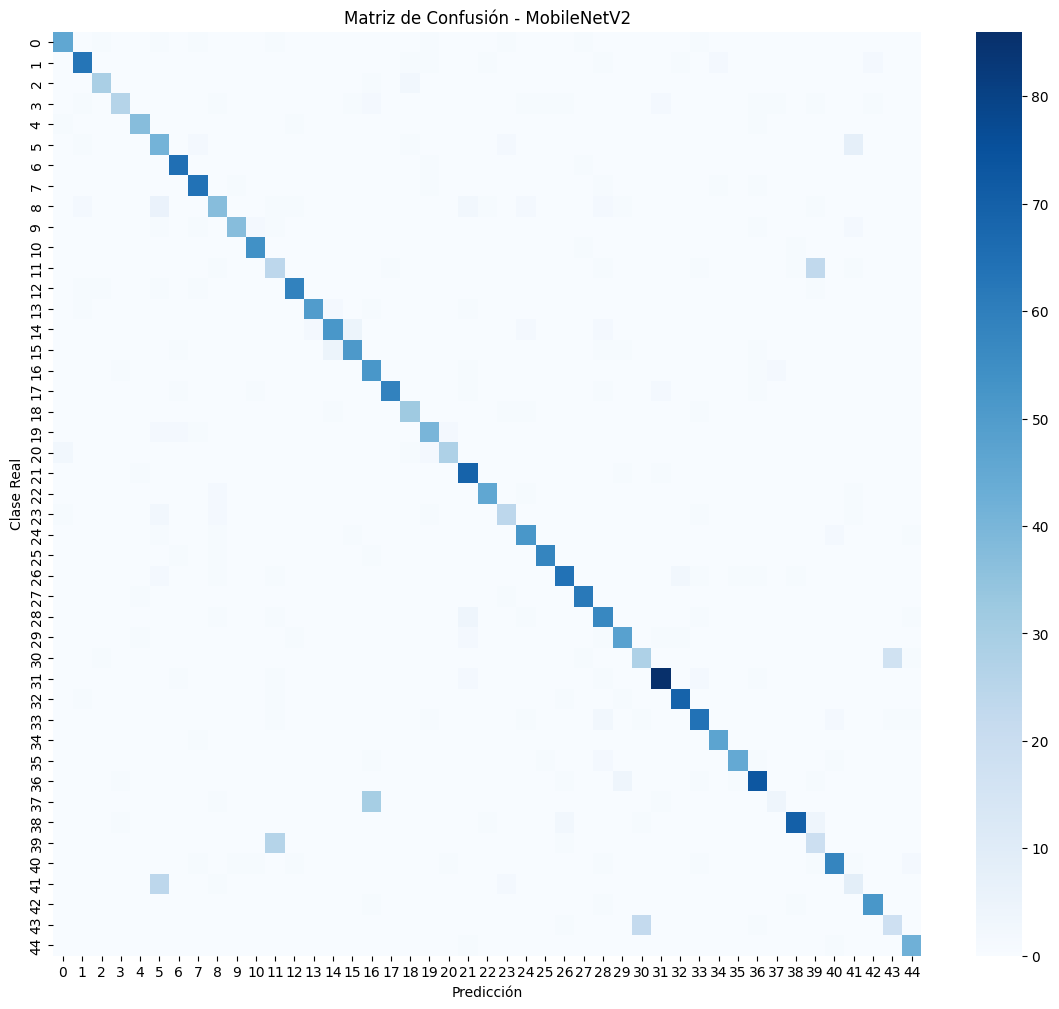

In [22]:
model = tf.keras.models.load_model(
    "modelo_aves_mobilenetv2_v1.keras"
)

test_generator.reset()

pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues")

plt.title("Matriz de Confusión - MobileNetV2")
plt.xlabel("Predicción")
plt.ylabel("Clase Real")

plt.show()

<h3 style="color:#0f172a;">⚠️ Top 10 Especies con Más Falsos Positivos</h3>

<div style="background-color:#fff1f2; padding:12px; border-radius:8px;">

Se identifican automáticamente las confusiones más frecuentes
del modelo.

</div>

In [25]:
for nombre, path in model_paths.items():

    print(f"\n⚠️ TOP CONFUSIONES — {nombre}")

    model = tf.keras.models.load_model(path)

    test_generator.reset()

    pred = model.predict(test_generator)
    y_pred = np.argmax(pred, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    top_confusions = np.dstack(
        np.unravel_index(
            np.argsort(cm_no_diag.ravel())[::-1],
            cm_no_diag.shape
        )
    )[0][:10]

    for real, pred in top_confusions:
        print(
            f"Real: {class_names[real]} "
            f"→ Predicha: {class_names[pred]} "
            f"| Errores: {cm[real,pred]}"
        )


⚠️ TOP CONFUSIONES — VGG16
80/80 ━━━━━━━━━━━━━━━━━━━━ 63s 765ms/step
Real: Tangara_Matorralera → Predicha: Tangara_Azulgris_Thraupis_episcopus | Errores: 73
Real: Carpintero_Pecho_Punteado → Predicha: Carpintero_Coronirrojo_Melanerpes_rubricapillus | Errores: 47
Real: Tangara_Azulgris_Thraupis_episcopus → Predicha: Tangara_Matorralera | Errores: 40
Real: Carpintero_Coronirrojo_Melanerpes_rubricapillus → Predicha: Carpintero_Pecho_Punteado | Errores: 39
Real: Halcon_Fajado_Falco_femoralis → Predicha: Halcon_Peregrino_Falco_peregrinus | Errores: 36
Real: Halcon_Peregrino_Falco_peregrinus → Predicha: Halcon_Fajado_Falco_femoralis | Errores: 26
Real: jilguero_dorado_Sicalis_flaveola → Predicha: Saffron_Finch | Errores: 26
Real: Centzontle_Tropical_Mimus_gilvus → Predicha: Tropical_Mockingbird | Errores: 25
Real: Thick_billed_Euphonia → Predicha: Eufonia_Piquigruesa_Euphonia_laniirostris | Errores: 20
Real: Zopilote_Comun_Coragyps_atratus → Predicha: Black_Vulture | Errores: 20

⚠️ TOP CON

/home/asnarck/tf_gpu/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 57 variables whereas the saved optimizer has 112 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


80/80 ━━━━━━━━━━━━━━━━━━━━ 57s 660ms/step
Real: Thick_billed_Euphonia → Predicha: Eufonia_Piquigruesa_Euphonia_laniirostris | Errores: 30
Real: Tropical_Mockingbird → Predicha: Centzontle_Tropical_Mimus_gilvus | Errores: 26
Real: Zopilote_Comun_Coragyps_atratus → Predicha: Black_Vulture | Errores: 24
Real: Centzontle_Tropical_Mimus_gilvus → Predicha: Tropical_Mockingbird | Errores: 23
Real: jilguero_dorado_Sicalis_flaveola → Predicha: Saffron_Finch | Errores: 22
Real: Saffron_Finch → Predicha: jilguero_dorado_Sicalis_flaveola | Errores: 17
Real: Black_Vulture → Predicha: Zopilote_Comun_Coragyps_atratus | Errores: 8
Real: Carib_Grackle → Predicha: Black_Vulture | Errores: 6
Real: Colibri_Florido_de_Tolima_Anthocephala_berlepschi → Predicha: Colibri_Cola_Canela_Amazilia_tzacatl | Errores: 5
Real: Colibri_Cola_Canela_Amazilia_tzacatl → Predicha: Colibri_Florido_de_Tolima_Anthocephala_berlepschi | Errores: 5


<h1 style="background-color:#1e293b; color:white; padding:12px; border-radius:8px;">
🟢 FASE 2 — Análisis del Diagnóstico y Diseño Jerárquico
</h1>

<div style="background-color:#f8fafc; padding:15px; border-radius:8px; border-left:6px solid #22c55e; font-family:Arial;">

<b>🎯 Objetivo:</b><br>
Interpretar los resultados obtenidos en la Fase 1 para comprender
las limitaciones reales de los modelos evaluados y proponer una
estrategia de especialización que mejore el reconocimiento de especies.

</div>

<h3 style="color:#0f172a;">🧠 Interpretación General de Resultados</h3>

<div style="background-color:#fafaf9; padding:12px; border-radius:8px;">

<b>Hallazgos principales:</b>

<ul>

<li>El modelo <b>MobileNetV2</b> presenta el mejor equilibrio general entre precisión y recall.</li>

<li>El modelo <b>VGG16 Fine-Tuned</b> muestra dificultades importantes en múltiples especies,
evidenciado por recalls cercanos a cero.</li>

<li><b>EfficientNetB0</b> evidencia colapso de aprendizaje, clasificando incorrectamente
gran parte de las especies.</li>

<li>Las matrices de confusión revelan que los errores no son aleatorios,
sino estructurados entre especies visualmente similares.</li>

<li>Existen grupos de aves altamente reconocibles y otros consistentemente problemáticos
en los tres modelos.</li>

</ul>

</div>

<h3 style="color:#0f172a;">🔴 Interpretación de Especies Problemáticas</h3>

<div style="background-color:#fff7ed; padding:12px; border-radius:8px;">

<b>Observaciones:</b>

<ul>

<li>Las especies con bajo recall aparecen repetidamente entre modelos,
lo que indica una dificultad visual intrínseca y no un fallo aislado.</li>

<li>Aves pequeñas o con patrones cromáticos similares presentan mayor tasa de confusión.</li>

<li>Variaciones de iluminación, distancia y fondo afectan principalmente
a especies con menor tamaño corporal.</li>

<li>El modelo general intenta aprender demasiadas clases simultáneamente,
reduciendo su capacidad discriminativa fina.</li>

</ul>

<b>Conclusión:</b><br>
El problema no se resuelve únicamente aumentando épocas de entrenamiento;
se requiere una arquitectura especializada.

</div>

<h3 style="color:#0f172a;">🟢 Interpretación de Especies Bien Aprendidas</h3>

<div style="background-color:#ecfdf5; padding:12px; border-radius:8px;">

<b>Patrones identificados:</b>

<ul>

<li>Las especies con alto desempeño poseen siluetas claramente diferenciables.</li>

<li>Presentan contrastes de color fuertes o rasgos morfológicos únicos.</li>

<li>El modelo aprende fácilmente aves grandes o con patrones visuales dominantes.</li>

<li>Estas especies sirven como base confiable dentro del sistema de clasificación.</li>

</ul>

</div>

<h3 style="color:#0f172a;">🔥 Interpretación de Matrices de Confusión</h3>

<div style="background-color:#eef2ff; padding:12px; border-radius:8px;">

<b>Lo que muestran las matrices:</b>

<ul>

<li>Las confusiones se concentran en bloques específicos de especies.</li>

<li>Se evidencia agrupamiento natural de aves similares.</li>

<li>El modelo general aprende categorías visuales implícitas
en lugar de especies individuales.</li>

<li>Esto sugiere que existe una estructura jerárquica natural
dentro del dataset.</li>

</ul>

<b>Insight clave:</b><br>
El modelo está intentando resolver un problema jerárquico
utilizando una arquitectura plana.

</div>

<h3 style="color:#0f172a;">🚀 Justificación del Modelo Jerárquico</h3>

<div style="background-color:#f1f5f9; padding:12px; border-radius:8px;">

A partir del diagnóstico realizado se propone abandonar el enfoque
de clasificación única y adoptar una estrategia jerárquica:

<ul>

<li><b>Modelo General:</b> identifica grandes grupos visuales de aves.</li>

<li><b>Modelos Especialistas:</b> clasifican especies similares dentro de cada grupo.</li>

<li>Reducción del espacio de decisión en cada etapa.</li>

<li>Mejora esperada del recall en especies problemáticas.</li>

</ul>

<b>Hipótesis central:</b><br>
Dividir el problema en sub-problemas visuales permitirá superar
el límite observado en los modelos generales.

</div>

<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Clínica de Modelos - Fase 1</title>

<style>

body{
    font-family: Arial;
    background:#f1f5f9;
    margin:40px;
}

h1{
    background:#0f172a;
    color:#38bdf8;
    padding:15px;
    border-radius:8px;
    text-align:center;
}

h2{
    background:#1e293b;
    color:white;
    padding:10px;
    border-radius:6px;
}

.grid{
    display:grid;
    grid-template-columns:repeat(auto-fill,minmax(200px,1fr));
    gap:20px;
}

.card{
    background:white;
    border-radius:10px;
    box-shadow:0 4px 10px rgba(0,0,0,0.1);
    text-align:center;
    padding:10px;
}

.card img{
    width:100%;
    height:160px;
    object-fit:cover;
    border-radius:8px;
}

.bad{
    border-left:6px solid #ef4444;
}

.good{
    border-left:6px solid #22c55e;
}

</style>
</head>

<body>

<h1>🧪 Clínica de Modelos — Diagnóstico Visual</h1>

<!-- ================= BAJO DESEMPEÑO ================= -->

<h2>🔴 Aves con Bajo Desempeño (Recall &lt; 0.60)</h2>

<div class="grid">

<div class="card bad">
<img src="dataset_limpio_v7/Thick_billed_Euphonia/Thick-billed Euphonia_13.jpg">
<p>Thick billed Euphonia</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/Zopilote_Comun_Coragyps_atratus/Zopilote_Comun_Coragyps_atratus_5.jpg">
<p>Zopilote Común</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/Tropical_Mockingbird/Tropical Mockingbird_3.jpg">
<p>Tropical Mockingbird</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/jilguero_dorado_Sicalis_flaveola/jilguero dorado_Sicalis flaveola_20.jpg">
<p>Jilguero Dorado</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/Centzontle_Tropical_Mimus_gilvus/Centzontle-Tropical-Mimus-gilvus_11.jpg">
<p>Centzontle Tropical</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/Saffron_Finch/Saffron Finch_2.jpg">
<p>Saffron Finch</p>
</div>

</div>

<br><br>

<!-- ================= ALTO DESEMPEÑO ================= -->

<h2>🟢 Aves con Alto Desempeño (Recall &gt; 0.85)</h2>

<div class="grid">

<div class="card good">
<img src="dataset_limpio_v7/Southern_Lapwing/Southern Lapwing_3.jpg">
<p>Southern Lapwing</p>
</div>

<div class="card good">
<img src="dataset_limpio_v7/Buco_Bobito/Buco Bobito_2.jpg">
<p>Buco Bobito</p>
</div>

<div class="card good">
<img src="dataset_limpio_v7/Moustached_Puffbird/Moustached Puffbird_0.jpg">
<p>Moustached Puffbird</p>
</div>

<div class="card good">
<img src="dataset_limpio_v7/Hormiguero_Ventriblanco/Hormiguero Ventriblanco_0.jpg">
<p>Hormiguero Ventriblanco</p>
</div>

<div class="card good">
<img src="dataset_limpio_v7/Momoto_Serrano_Momotus_aequatorialis/Momoto-Serrano-Momotus-aequatorialis_0.jpg">
<p>Momoto Serrano</p>
</div>

<div class="card good">
<img src="dataset_limpio_v7/benteveo_pitangus_sulphuratus/benteveo_pitangus_sulphuratus_6.jpg">
<p>Benteveo</p>
</div>

</div>

</body>
</html>

<h1 style="background-color:#f59e0b; color:white; padding:14px; border-radius:8px;">
🟡 FASE 2.1 — Diagnóstico de Confusiones del Modelo
</h1>

<div style="background-color:#fff7ed; padding:15px; border-radius:8px; border-left:6px solid #f59e0b; font-family:Arial;">

<b>🎯 Objetivo:</b><br>
Identificar exactamente <b>dónde se rompe el modelo MobileNetV2</b> mediante el análisis
de la matriz de confusión y la detección de especies que el sistema confunde con mayor frecuencia.

<br><br>

<b>🧠 Pregunta clínica:</b><br>
¿El modelo falla por falta de datos o porque existen especies visualmente similares?

<br><br>

<b>Resultados esperados:</b>
<ul>
<li>✔ Matriz de Confusión</li>
<li>✔ Visualización Heatmap</li>
<li>✔ Top confusiones críticas</li>
<li>✔ Evidencia para diseño jerárquico</li>
</ul>

</div>

<h1>🟡 Clínica de Modelos — Diagnóstico de Confusiones</h1>

<h2>🔥 Confusiones Críticas Detectadas</h2>

<div class="grid">

<div class="card bad">
<img src="dataset_limpio_v7/Thick_billed_Euphonia/Thick-billed Euphonia_13.jpg">
<p><b>REAL:</b> Thick billed Euphonia</p>
<p><b>PREDICHO:</b> Saffron Finch</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/jilguero_dorado_Sicalis_flaveola/jilguero dorado_Sicalis flaveola_20.jpg">
<p><b>REAL:</b> Jilguero Dorado</p>
<p><b>PREDICHO:</b> Tropical Mockingbird</p>
</div>

<div class="card bad">
<img src="dataset_limpio_v7/Zopilote_Comun_Coragyps_atratus/Zopilote_Comun_Coragyps_atratus_5.jpg">
<p><b>REAL:</b> Zopilote Común</p>
<p><b>PREDICHO:</b> Caracara Cabeza Amarilla</p>
</div>

</div>

<h3 style="color:#0f172a;">📊 Paso 1 — Construcción de la Matriz de Confusión</h3>

<div style="background-color:#ecfeff; padding:12px; border-radius:8px;">
Se evalúa el modelo MobileNetV2 sobre el conjunto de validación para comparar
las etiquetas reales contra las predicciones generadas por la red neuronal.
</div>

In [34]:
from sklearn.metrics import confusion_matrix

model = tf.keras.models.load_model(
    "modelo_aves_mobilenetv2_v1.keras"
)

test_generator.reset()

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

print("✅ Matriz de confusión generada")

/home/asnarck/tf_gpu/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 57 variables whereas the saved optimizer has 112 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


80/80 ━━━━━━━━━━━━━━━━━━━━ 53s 600ms/step
✅ Matriz de confusión generada


<h3 style="color:#0f172a;">🔥 Paso 2 — Visualización Heatmap</h3>

<div style="background-color:#f1f5f9; padding:12px; border-radius:8px;">
El mapa de calor permite observar visualmente los patrones de error del modelo.
Los valores fuera de la diagonal representan confusiones entre especies.
</div>

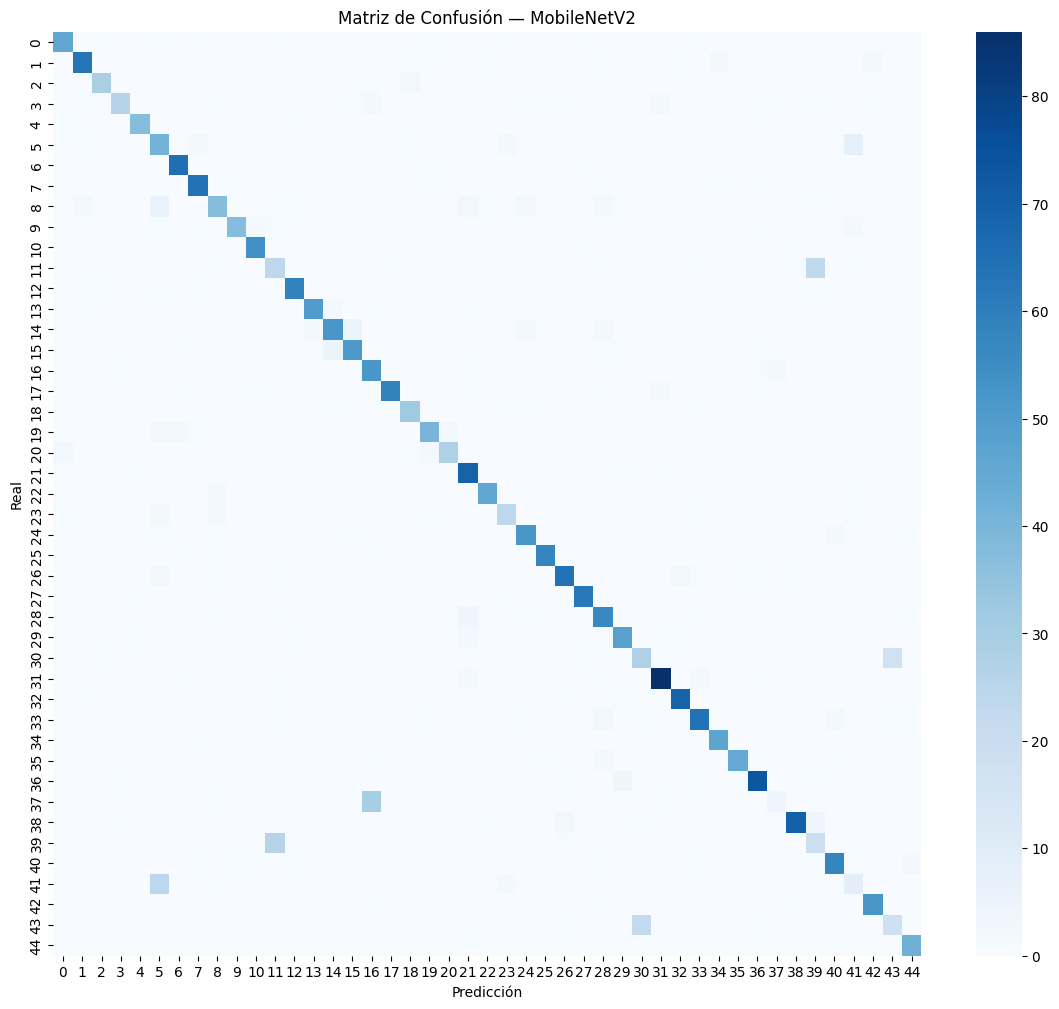

In [36]:
plt.figure(figsize=(14,12))

sns.heatmap(cm, cmap="Blues")

plt.title("Matriz de Confusión — MobileNetV2")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

<h2>Análisis de Resultados — Fase 2: Matriz de Confusión (MobileNetV2)</h2>

<p>
La matriz de confusión permite evaluar el desempeño del modelo MobileNetV2 en la 
clasificación de especies. En este gráfico, las filas representan las clases reales 
y las columnas las clases predichas por el modelo.
</p>

<h3>Interpretación General</h3>
<ul>
    <li>
        Se observa una fuerte concentración de valores sobre la diagonal principal,
        lo que indica que el modelo realiza predicciones correctas en la mayoría de
        las clases.
    </li>
    <li>
        La intensidad del color azul en la diagonal evidencia un alto número de
        aciertos por especie, mostrando una buena capacidad de reconocimiento.
    </li>
</ul>

<h3>Errores de Clasificación</h3>
<ul>
    <li>
        Algunos puntos fuera de la diagonal representan confusiones entre especies.
    </li>
    <li>
        Estas confusiones pueden deberse a similitud visual entre especies,
        baja cantidad de imágenes de entrenamiento o variaciones en iluminación,
        fondo o ángulo de captura.
    </li>
</ul>

<h3>Conclusiones del Diagnóstico</h3>
<ul>
    <li>
        El modelo presenta un rendimiento general alto, evidenciado por la
        predominancia de predicciones correctas.
    </li>
    <li>
        Existen especies específicas con menor desempeño que requieren análisis
        adicional mediante métricas como recall, precision y F1-score.
    </li>
    <li>
        La matriz de confusión permite identificar clases problemáticas que serán
        objetivo de mejora en fases posteriores del proyecto.
    </li>
</ul>

<h3>Recomendaciones</h3>
<ul>
    <li>Aumentar datos en especies con menor recall.</li>
    <li>Aplicar técnicas de data augmentation.</li>
    <li>Revisar posibles desbalances entre clases.</li>
</ul>

In [40]:
df.columns

Index(['precision', 'recall', 'f1-score', 'support'], dtype='object')

In [58]:
import os
os.listdir()

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 '.vscode',
 '1_detectar_recortar.py',
 'AVES',
 'AVES_PROCESADAS_2',
 'Codigo_prepocesamiento_Limpieza.txt',
 'dataset_especialista',
 'dataset_limpio_v7',
 'dataset_limpio_v7_Mejora',
 'dataset_original',
 'EfficientNetB0_Fase1_taller_sobreAjuste.keras',
 'EfficientNetB0_Fase2_finetune_taller.keras',
 'ENTREGA_KEVIN_LAURA_ARQUITECTURAS_EXPLICABILIDAD',
 'ENTREGA_KEVIN_LAURA_ARQUITECTURAS_EXPLICABILIDAD.zip',
 'Entrenamiento_CNN_MobileNetV2.ipynb',
 'Entrenamiento_con_MobileNetV2',
 'Entrenamiento_con_MobileNetV2.zip',
 'Entrenamiento_EfficientNetB0.ipynb',
 'Entrenamiento_EfficientNetB0_v1.keras',
 'entrenamiento_vgg16.ipynb',
 'entrenar_vgg16_backup.py',
 'Entreneamientos_Kevin_Laura.zip',
 'Entreneamiento_Kevin_Laura_sobreAjuste.zip',
 'labels_aves.txt',
 'limpiarAVEsola',
 'modelo_aves_mobilenetv2_v1.keras',
 'modelo_aves_mobilenetv2_v1.tflite',
 'modelo_aves_vgg16.keras',
 'modelo_aves_vgg16_control_sobreajuste_V2_Fase1.keras',
 'mod

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "dataset_limpio_v7",   # ✅ ESTA ES TU RUTA REAL
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 12772 images belonging to 45 classes.


In [52]:
import os
import pandas as pd

ruta = "dataset_limpio_v7"

conteo = {}

for clase in os.listdir(ruta):
    ruta_clase = os.path.join(ruta, clase)
    
    if os.path.isdir(ruta_clase):
        conteo[clase] = len(os.listdir(ruta_clase))

df_conteo = pd.DataFrame.from_dict(conteo, orient='index', columns=['imagenes_actuales'])
df_conteo = df_conteo.sort_values(by='imagenes_actuales')

df_conteo

,imagenes_actuales
Aratinga_Pertinaz_Eupsittula_pertinax,166
Loro_Alibronceado,166
Halcon_Peregrino_Falco_peregrinus,171
Guacamayo_Severo,181
Thick_billed_Euphonia,181
Zopilote_Comun_Coragyps_atratus,184
Barred_Antshrike,201
Bananaquit,204
jilguero_dorado_Sicalis_flaveola,211
tortolita_canela_Columbina_talpacoti,222


In [53]:
# promedio del dataset
objetivo = int(df_conteo['imagenes_actuales'].mean())

print("🎯 Objetivo por clase:", objetivo)

🎯 Objetivo por clase: 283


In [54]:
df_conteo['faltantes'] = objetivo - df_conteo['imagenes_actuales']

# solo clases que necesitan imágenes
df_faltantes = df_conteo[df_conteo['faltantes'] > 0]

df_faltantes = df_faltantes.sort_values(by='faltantes', ascending=False)

df_faltantes

,imagenes_actuales,faltantes
Aratinga_Pertinaz_Eupsittula_pertinax,166,117
Loro_Alibronceado,166,117
Halcon_Peregrino_Falco_peregrinus,171,112
Guacamayo_Severo,181,102
Thick_billed_Euphonia,181,102
Zopilote_Comun_Coragyps_atratus,184,99
Barred_Antshrike,201,82
Bananaquit,204,79
jilguero_dorado_Sicalis_flaveola,211,72
tortolita_canela_Columbina_talpacoti,222,61


In [55]:
def nivel(faltan):
    if faltan > 100:
        return "🔴 CRÍTICO"
    elif faltan > 50:
        return "🟠 MEDIO"
    elif faltan > 0:
        return "🟡 LEVE"
    else:
        return "🟢 OK"

df_conteo['nivel'] = df_conteo['faltantes'].apply(nivel)

df_conteo.sort_values(by='faltantes', ascending=False)

,imagenes_actuales,faltantes,nivel
Aratinga_Pertinaz_Eupsittula_pertinax,166,117,🔴 CRÍTICO
Loro_Alibronceado,166,117,🔴 CRÍTICO
Halcon_Peregrino_Falco_peregrinus,171,112,🔴 CRÍTICO
Guacamayo_Severo,181,102,🔴 CRÍTICO
Thick_billed_Euphonia,181,102,🔴 CRÍTICO
Zopilote_Comun_Coragyps_atratus,184,99,🟠 MEDIO
Barred_Antshrike,201,82,🟠 MEDIO
Bananaquit,204,79,🟠 MEDIO
jilguero_dorado_Sicalis_flaveola,211,72,🟠 MEDIO
tortolita_canela_Columbina_talpacoti,222,61,🟠 MEDIO


In [56]:
df_importantes = df_conteo[df_conteo['nivel'].isin(["🔴 CRÍTICO", "🟠 MEDIO"])]

df_importantes.sort_values(by='faltantes', ascending=False)

,imagenes_actuales,faltantes,nivel
Aratinga_Pertinaz_Eupsittula_pertinax,166,117,🔴 CRÍTICO
Loro_Alibronceado,166,117,🔴 CRÍTICO
Halcon_Peregrino_Falco_peregrinus,171,112,🔴 CRÍTICO
Guacamayo_Severo,181,102,🔴 CRÍTICO
Thick_billed_Euphonia,181,102,🔴 CRÍTICO
Zopilote_Comun_Coragyps_atratus,184,99,🟠 MEDIO
Barred_Antshrike,201,82,🟠 MEDIO
Bananaquit,204,79,🟠 MEDIO
jilguero_dorado_Sicalis_flaveola,211,72,🟠 MEDIO
tortolita_canela_Columbina_talpacoti,222,61,🟠 MEDIO


In [57]:
for clase, row in df_importantes.iterrows():
    print(f"{clase} → descargar aprox {int(row['faltantes'])} imágenes")

Aratinga_Pertinaz_Eupsittula_pertinax → descargar aprox 117 imágenes
Loro_Alibronceado → descargar aprox 117 imágenes
Halcon_Peregrino_Falco_peregrinus → descargar aprox 112 imágenes
Guacamayo_Severo → descargar aprox 102 imágenes
Thick_billed_Euphonia → descargar aprox 102 imágenes
Zopilote_Comun_Coragyps_atratus → descargar aprox 99 imágenes
Barred_Antshrike → descargar aprox 82 imágenes
Bananaquit → descargar aprox 79 imágenes
jilguero_dorado_Sicalis_flaveola → descargar aprox 72 imágenes
tortolita_canela_Columbina_talpacoti → descargar aprox 61 imágenes
Carpintero_Coronirrojo_Melanerpes_rubricapillus → descargar aprox 54 imágenes
Tropical_Mockingbird → descargar aprox 51 imágenes


<h3 style="color:#0f172a;">📊 Análisis de Balance del Dataset</h3>

<div style="background-color:#fafaf9; padding:12px; border-radius:8px;">

<b>Observación crítica:</b>

<ul>
<li>El dataset presenta un fuerte desbalance entre clases.</li>
<li>Algunas especies tienen menos de 10 imágenes, lo que impide un aprendizaje robusto.</li>
<li>Las especies con menor cantidad coinciden con bajo recall en el modelo.</li>
<li>El modelo favorece clases con mayor representación (sesgo de entrenamiento).</li>
</ul>

<b>Conclusión:</b>
El bajo desempeño no solo es problema del modelo, sino del dataset.ENTONCES haremos un V2 del proyecto utilizaremos nuestro 
script con nuevas imagenes de las aves que nos hace falta

</div>